# Microbiome & IBD Study — Step 2: Preprocessing

Based on the EDA findings, we need to address:

| Issue | Solution |
|---|---|
| `fecalcal` has 60% NaN | Drop as feature |
| 440 bacteria with >90% zeros | Remove low-prevalence features |
| Abundances are right-skewed | CLR transformation |
| Class imbalance (CD 47%, UC 27%, H 26%) | Compare SMOTE vs class_weight |
| **Longitudinal structure (multiple samples per patient)** | **GroupShuffleSplit — patients never split across train/test** |

**Key design decision:** The dataset contains 3,387 samples from only **116 patients** (mean 29.2 samples/patient). A random split would place samples from the same patient in both train and test, causing **data leakage** and artificially inflating performance. We use `GroupShuffleSplit` to ensure each patient appears entirely in either train or test — never both.

This approach mirrors clinical reality: we want to predict diagnosis for **new patients**, not new time points from known patients.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/Microbiome_Metagenomics.csv')
print(f'Dataset shape: {df.shape}')
print(f'Unique patients: {df["Participant ID"].nunique()}')
print(f'Samples per patient: min={df.groupby("Participant ID").size().min()}, '
      f'max={df.groupby("Participant ID").size().max()}, '
      f'mean={df.groupby("Participant ID").size().mean():.1f}')

Dataset shape: (3387, 571)
Unique patients: 116
Samples per patient: min=1, max=67, mean=29.2


## 2.1 Separate Metadata and Features

In [10]:
meta_cols = ['External ID', 'Participant ID', 'week_num', 'diagnosis', 'fecalcal']
bacteria_cols = [c for c in df.columns if c not in meta_cols]

print(f'Bacterial species (original): {len(bacteria_cols)}')
print(f'Metadata columns            : {meta_cols}')

# Patient-level class distribution
patient_diag = df.drop_duplicates('Participant ID')['diagnosis'].value_counts()
print(f'\nPatient-level class distribution:')
print(patient_diag)

Bacterial species (original): 566
Metadata columns            : ['External ID', 'Participant ID', 'week_num', 'diagnosis', 'fecalcal']

Patient-level class distribution:
diagnosis
Crohns Disease        56
Ulcerative Colitis    33
Healthy               27
Name: count, dtype: int64


## 2.2 Drop Low-Prevalence Features

**Justification:** 440 out of 566 bacteria are zero in >90% of samples. We keep only bacteria present in at least 10% of samples, a threshold slightly stricter than Su et al. (2022) who use 5%, but justified by our higher sparsity.

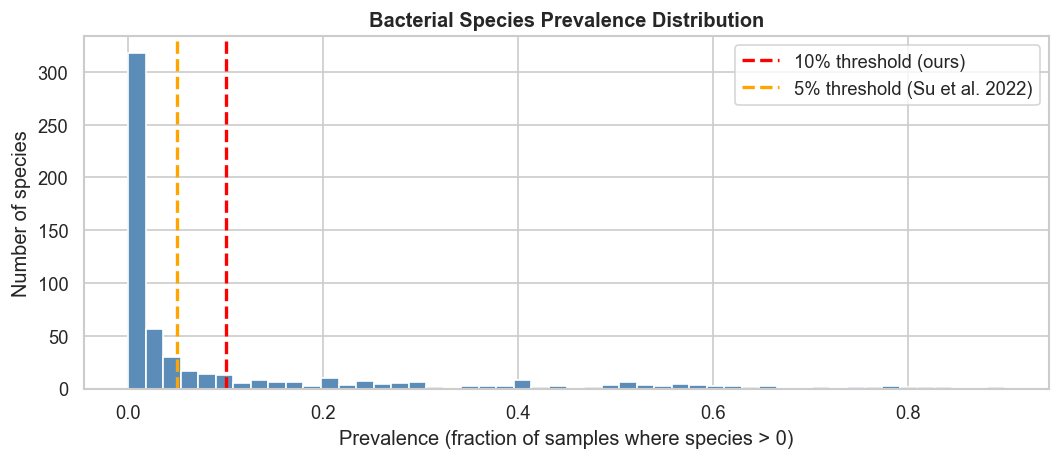

Species kept (>=10% prevalence): 126
Species removed               : 440


In [11]:
prevalence = (df[bacteria_cols] > 0).mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(prevalence.values, bins=50, color='#5b8db8', edgecolor='white')
ax.axvline(0.10, color='red',    linestyle='--', linewidth=2, label='10% threshold (ours)')
ax.axvline(0.05, color='orange', linestyle='--', linewidth=2, label='5% threshold (Su et al. 2022)')
ax.set_xlabel('Prevalence (fraction of samples where species > 0)')
ax.set_ylabel('Number of species')
ax.set_title('Bacterial Species Prevalence Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/07_prevalence.png', bbox_inches='tight')
plt.show()

keep_bacteria = prevalence[prevalence >= 0.10].index.tolist()
print(f'Species kept (>=10% prevalence): {len(keep_bacteria)}')
print(f'Species removed               : {len(bacteria_cols) - len(keep_bacteria)}')

## 2.3 CLR Transformation

**Justification:** Microbiome relative abundance data is **compositional** — values sum to 1 per sample, creating spurious correlations. The Centered Log-Ratio (CLR) transformation corrects this (Aitchison, 1986). Unlike Su et al. (2022) and Manandhar et al. (2021) who use raw abundances, we apply CLR to reduce skewness and compositionality bias.

Formula: `CLR(x_i) = log(x_i / geometric_mean(x))`

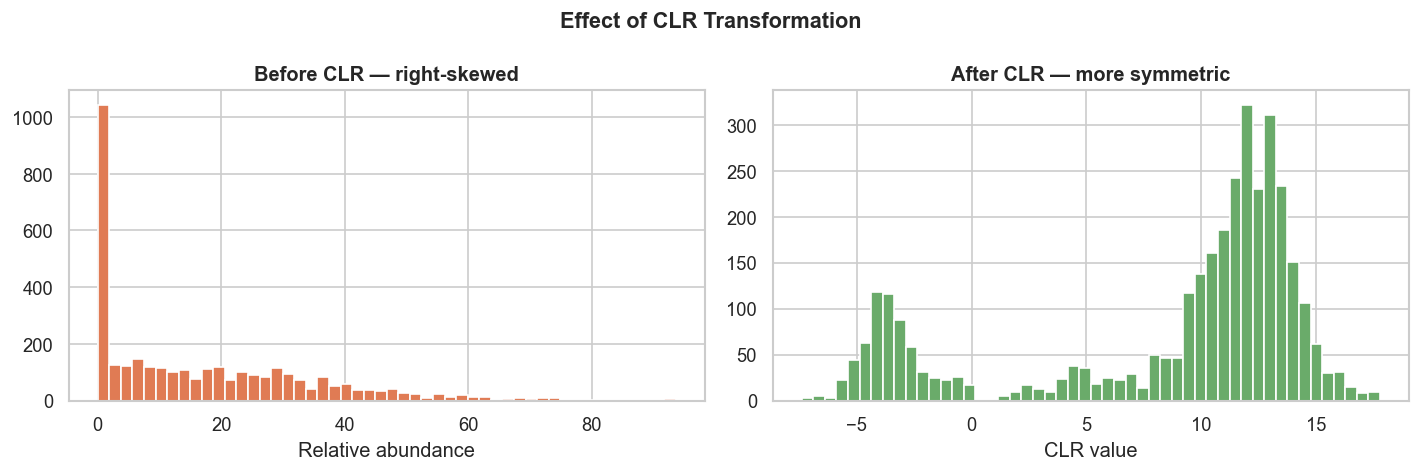

In [12]:
def clr_transform(X, pseudocount=1e-6):
    """Centered Log-Ratio transformation for compositional microbiome data."""
    X_pseudo = X + pseudocount
    log_X    = np.log(X_pseudo)
    return log_X - log_X.mean(axis=1, keepdims=True)

X_clr = clr_transform(df[keep_bacteria].values)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[keep_bacteria].values[:, 0], bins=50, color='#e07b54', edgecolor='white')
axes[0].set_title('Before CLR — right-skewed', fontweight='bold')
axes[0].set_xlabel('Relative abundance')
axes[1].hist(X_clr[:, 0], bins=50, color='#6aab6a', edgecolor='white')
axes[1].set_title('After CLR — more symmetric', fontweight='bold')
axes[1].set_xlabel('CLR value')
plt.suptitle('Effect of CLR Transformation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/08_clr_transformation.png', bbox_inches='tight')
plt.show()

## 2.4 Encode Target Variable

In [13]:
le = LabelEncoder()
y      = le.fit_transform(df['diagnosis'])
groups = df['Participant ID'].values  # patient IDs for GroupShuffleSplit

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')
print(f'\nUnique groups (patients): {len(np.unique(groups))}')

Label encoding:
  0 → Crohns Disease
  1 → Healthy
  2 → Ulcerative Colitis

Unique groups (patients): 116


## 2.5 Group-Based Train/Test Split

**Justification:** The dataset is longitudinal — 116 patients each contribute ~29 samples across 57 weeks. A random split would leak patient information from train to test, artificially inflating performance metrics.

`GroupShuffleSplit` ensures **no patient appears in both train and test**. This gives a realistic estimate of how the model would perform on a completely new patient — the clinically relevant scenario.

We compare three test sizes (15%, 20%, 30%) at the patient level.

In [14]:
split_configs = {
    '85/15': 0.15,
    '80/20': 0.20,
    '70/30': 0.30
}

split_results = {}

for name, test_size in split_configs.items():
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    train_idx, test_idx = next(gss.split(X_clr, y, groups=groups))

    split_results[name] = {
        'train_idx': train_idx,
        'test_idx':  test_idx,
        'X_train': X_clr[train_idx],
        'X_test':  X_clr[test_idx],
        'y_train': y[train_idx],
        'y_test':  y[test_idx],
        'groups_train': groups[train_idx]
    }

    # Verify no patient overlap
    train_patients = set(groups[train_idx])
    test_patients  = set(groups[test_idx])
    overlap = train_patients & test_patients

    print(f'Split {name}: train={len(train_idx)} samples ({len(train_patients)} patients), '
          f'test={len(test_idx)} samples ({len(test_patients)} patients), '
          f'patient overlap={len(overlap)} ✓')

Split 85/15: train=2912 samples (98 patients), test=475 samples (18 patients), patient overlap=0 ✓
Split 80/20: train=2744 samples (92 patients), test=643 samples (24 patients), patient overlap=0 ✓
Split 70/30: train=2486 samples (81 patients), test=901 samples (35 patients), patient overlap=0 ✓


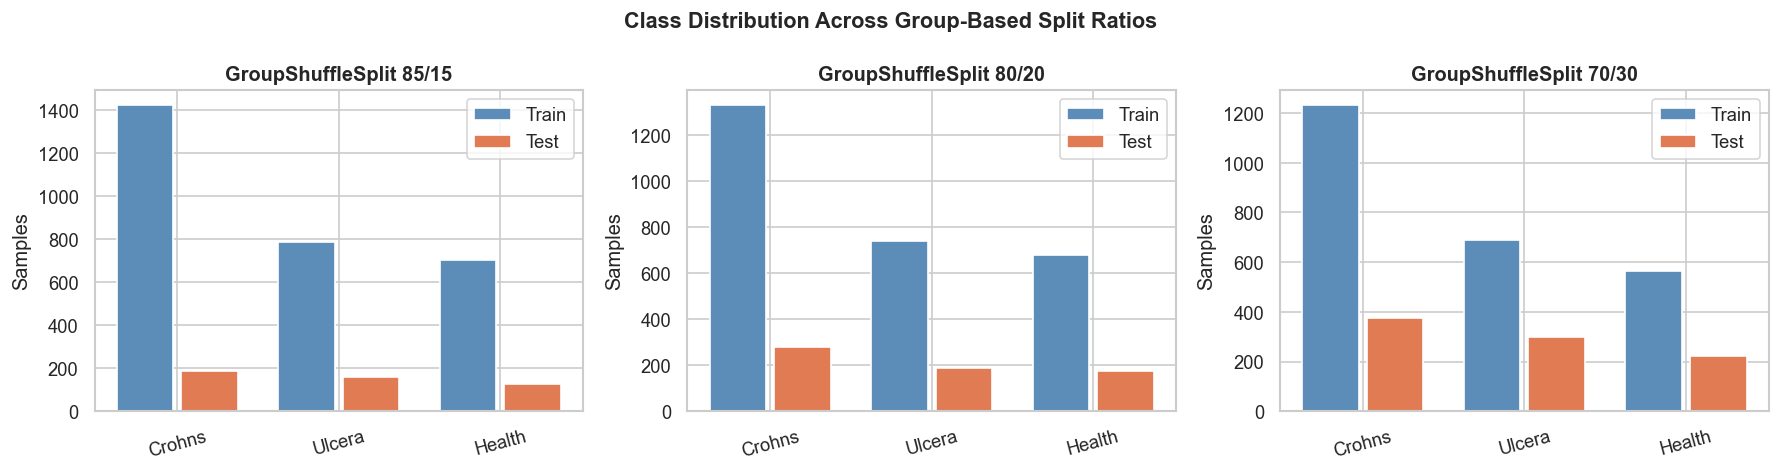

In [15]:
# Visualise class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, data) in zip(axes, split_results.items()):
    train_counts = pd.Series(data['y_train']).map(
        {i: c for i, c in enumerate(le.classes_)}).value_counts()
    test_counts  = pd.Series(data['y_test']).map(
        {i: c for i, c in enumerate(le.classes_)}).value_counts()

    x = np.arange(len(train_counts))
    ax.bar(x - 0.2, train_counts.values, 0.35, label='Train', color='#5b8db8', edgecolor='white')
    ax.bar(x + 0.2, test_counts.values,  0.35, label='Test',  color='#e07b54', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([c[:6] for c in train_counts.index], rotation=15)
    ax.set_title(f'GroupShuffleSplit {name}', fontweight='bold')
    ax.legend()
    ax.set_ylabel('Samples')

plt.suptitle('Class Distribution Across Group-Based Split Ratios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/09_group_split_comparison.png', bbox_inches='tight')
plt.show()

## 2.6 StandardScaler + Imbalance Strategies

We scale each split independently (fit on train only) and prepare both imbalance strategies:
- **SMOTE** (Freitas et al. 2023): synthetic oversampling of minority classes
- **class_weight='balanced'** (Su et al. 2022): passed as model parameter — no preprocessing needed

Split 85/15: scaled train=2912, SMOTE train=4263, test=475
Split 80/20: scaled train=2744, SMOTE train=3987, test=643
Split 70/30: scaled train=2486, SMOTE train=3693, test=901


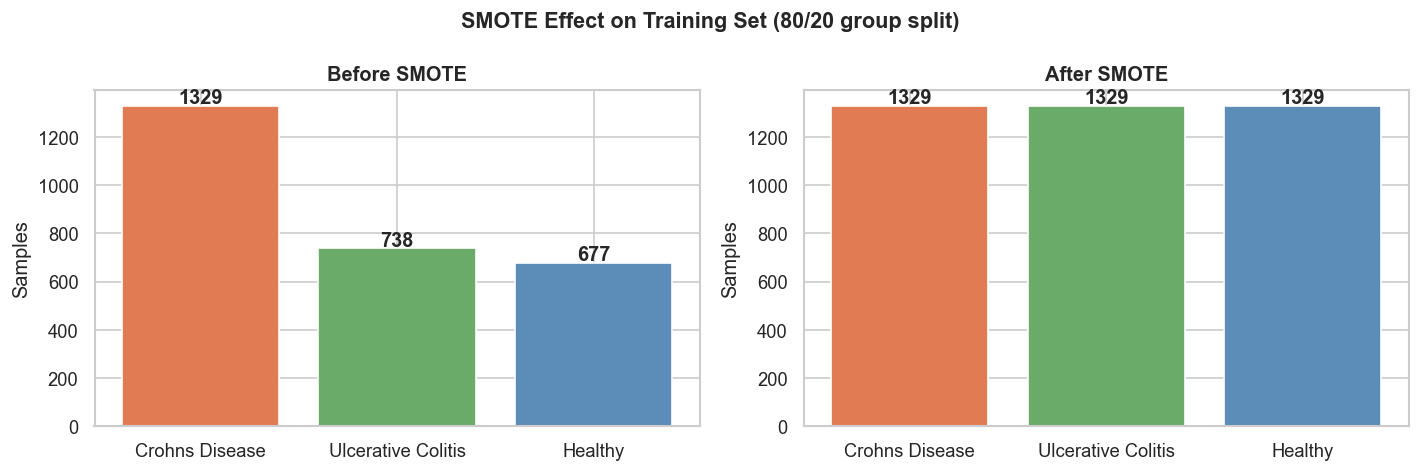

In [16]:
smote = SMOTE(random_state=42)

for name, data in split_results.items():
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(data['X_train'])
    X_te_sc = scaler.transform(data['X_test'])

    # Apply SMOTE to training set only
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, data['y_train'])

    split_results[name]['X_train_scaled'] = X_tr_sc
    split_results[name]['X_test_scaled']  = X_te_sc
    split_results[name]['X_train_smote']  = X_tr_sm
    split_results[name]['y_train_smote']  = y_tr_sm
    split_results[name]['scaler']         = scaler

    print(f'Split {name}: scaled train={X_tr_sc.shape[0]}, SMOTE train={X_tr_sm.shape[0]}, test={X_te_sc.shape[0]}')

# Visualise SMOTE effect on 80/20 split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
before = pd.Series(split_results['80/20']['y_train']).map(
    {i: c for i, c in enumerate(le.classes_)}).value_counts()
after  = pd.Series(split_results['80/20']['y_train_smote']).map(
    {i: c for i, c in enumerate(le.classes_)}).value_counts()
bar_colors = ['#e07b54', '#6aab6a', '#5b8db8']

for ax, (counts, title) in zip(axes, [
    (before, 'Before SMOTE'),
    (after,  'After SMOTE')
]):
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Samples')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('SMOTE Effect on Training Set (80/20 group split)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/10_smote_effect.png', bbox_inches='tight')
plt.show()

## 2.7 Save All Variants

In [17]:
import os
os.makedirs('../data/processed', exist_ok=True)

for name, data in split_results.items():
    key = name.replace('/', '_')
    # class_weight version (no SMOTE)
    np.save(f'../data/processed/X_train_{key}.npy',       data['X_train_scaled'])
    np.save(f'../data/processed/X_test_{key}.npy',        data['X_test_scaled'])
    np.save(f'../data/processed/y_train_{key}.npy',       data['y_train'])
    np.save(f'../data/processed/y_test_{key}.npy',        data['y_test'])
    np.save(f'../data/processed/groups_train_{key}.npy',  data['groups_train'])
    # SMOTE version
    np.save(f'../data/processed/X_train_{key}_smote.npy', data['X_train_smote'])
    np.save(f'../data/processed/y_train_{key}_smote.npy', data['y_train_smote'])
    print(f'Saved split {name}')

# Save feature and class names
pd.Series(keep_bacteria).to_csv('../data/processed/feature_names.csv', index=False)
pd.Series(le.classes_).to_csv('../data/processed/class_names.csv', index=False)
# Save full groups array for notebook 3
np.save('../data/processed/groups_all.npy', groups)
np.save('../data/processed/y_all.npy', y)
np.save('../data/processed/X_all.npy', X_clr)

print(f'\nFeatures: {len(keep_bacteria)}, Classes: {list(le.classes_)}')

Saved split 85/15
Saved split 80/20
Saved split 70/30

Features: 126, Classes: ['Crohns Disease', 'Healthy', 'Ulcerative Colitis']


## 2.8 Preprocessing Summary

| Step | Action | Justification |
|---|---|---|
| Drop `fecalcal` | Removed from features | 60% missing values |
| Prevalence filter | Kept species in ≥10% samples | Removes ultra-rare taxa noise |
| CLR transform | `log(x / geometric_mean(x))` | Corrects compositionality (Aitchison, 1986) |
| **GroupShuffleSplit** | **Split by patient ID, not sample** | **Prevents longitudinal leakage** |
| StandardScaler | Fit on train only | Prevents data leakage |
| Imbalance | SMOTE vs class_weight compared | Best selected in modelling notebook |

**Critical improvement over naive split:** By grouping samples by Participant ID, we ensure the model is evaluated on entirely unseen patients — the clinically meaningful test of generalisation.